# 한국 식품 영양성분 데이터 탐색적 분석 (EDA)

이 노트북에서는 식품의약품안전처에서 제공하는 식품 영양성분 데이터를 탐색적으로 분석합니다.
주요 분석 내용:
1. 데이터 기본 구조 및 품질 확인
2. 결측치 및 이상치 분석
3. 영양성분 분포 분석
4. 식품 카테고리별 영양성분 분석
5. 영양성분 간 상관관계 분석

## 1. 필요한 라이브러리 임포트

In [1]:
%pip install plotly

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/bf/6f/759d5da0517547a5d38aabf05d04d9f8adf83391d2c7fc33f904417d3ba2/plotly-6.1.2-py3-none-any.whl (16.3 MB)
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/bf/6f/759d5da0517547a5d38aabf05d04d9f8adf83391d2c7fc33f904417d3ba2/plotly-6.1.2-py3-none-any.whl (16.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 데이터 처리
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.font_manager as fm

In [3]:
# 시각화

from matplotlib import rc  ### 이 줄과
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:

# 프로젝트 루트 경로 (현재 노트북 위치 기준)
PROJECT_ROOT = Path().absolute().parent

rc('font', family='AppleGothic') 			## 이 두 줄을 
plt.rcParams['axes.unicode_minus'] = False  ## 추가해줍니다. 



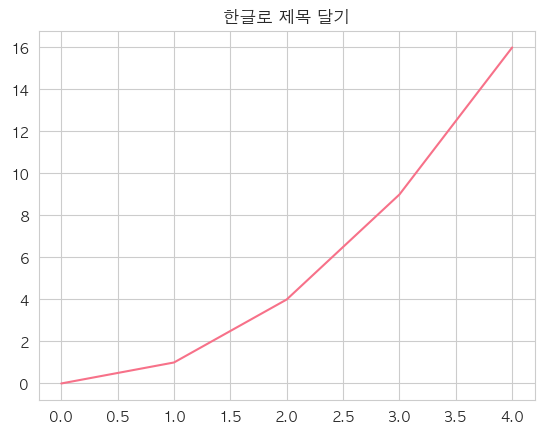

In [ ]:
# sample plot with Korean title
plt.figure()
plt.plot([i**2 for i in range(5)])
plt.title('한글로 제목 달기')
plt.show()

## 2. 데이터 불러오기

In [27]:
# 프로젝트 루트 디렉토리 설정
PROJECT_ROOT = Path().absolute().parent

# 데이터 파일 경로
file_path = PROJECT_ROOT / "data/koreaFDA/식품의약품안전처_통합식품영양성분정보(음식)_20250408.csv"

# 데이터 로드
df = pd.read_csv(file_path)

print(f"데이터 크기: {df.shape}")
print("\n처음 5개 행:")
df.head()

데이터 크기: (14584, 49)

처음 5개 행:


,식품코드,식품명,데이터구분코드,데이터구분명,식품기원코드,식품기원명,식품대분류코드,식품대분류명,대표식품코드,대표식품명,...,포화지방산(g),트랜스지방산(g),출처코드,출처명,식품중량,업체명,데이터생성방법코드,데이터생성방법명,데이터생성일자,데이터기준일자
0,D101-004160000-0001,국밥_돼지머리,D,음식,1,가정식(분석 함량),1,밥류,1004,국밥,...,1.47,0.03,3,식품의약품안전처,900g,해당없음,1,분석,2017-12-31,2025-04-08
1,D101-004310000-0001,국밥_순대국밥,D,음식,1,가정식(분석 함량),1,밥류,1004,국밥,...,1.26,0.01,3,식품의약품안전처,900g,해당없음,1,분석,2017-12-31,2025-04-08
2,D101-004500000-0001,국밥_콩나물,D,음식,1,가정식(분석 함량),1,밥류,1004,국밥,...,0.12,0.00,3,식품의약품안전처,780g,해당없음,1,분석,2018-12-31,2025-04-08
3,D101-006000000-0001,기장밥,D,음식,1,가정식(분석 함량),1,밥류,1006,기장밥,...,0.08,0.00,3,식품의약품안전처,200g,해당없음,1,분석,2017-12-31,2025-04-08
4,D101-007000000-0001,김밥,D,음식,1,가정식(분석 함량),1,밥류,1007,김밥,...,1.10,0.02,3,식품의약품안전처,230g,해당없음,1,분석,2018-12-31,2025-04-08


## 3. 데이터 기본 정보 확인

데이터의 기본 구조, 컬럼 정보, 데이터 타입 등을 확인합니다.

In [28]:
# 데이터 정보 확인
print("데이터 정보:")
df.info()

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14584 entries, 0 to 14583
Data columns (total 49 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   식품코드           14584 non-null  object 
 1   식품명            14584 non-null  object 
 2   데이터구분코드        14584 non-null  object 
 3   데이터구분명         14584 non-null  object 
 4   식품기원코드         14584 non-null  int64  
 5   식품기원명          14584 non-null  object 
 6   식품대분류코드        14584 non-null  int64  
 7   식품대분류명         14584 non-null  object 
 8   대표식품코드         14584 non-null  int64  
 9   대표식품명          14584 non-null  object 
 10  식품중분류코드        14584 non-null  int64  
 11  식품중분류명         14584 non-null  object 
 12  식품소분류코드        14584 non-null  int64  
 13  식품소분류명         14584 non-null  object 
 14  식품세분류코드        14584 non-null  int64  
 15  식품세분류명         14584 non-null  object 
 16  영양성분함량기준량      14584 non-null  object 
 17  에너지(kcal)      14584 non-null  int64  
 18

## 4. 결측치 및 이상치 분석

데이터의 결측치와 이상치를 분석하여 데이터 품질을 확인합니다.

결측치 분석:


,결측치 수,결측치 비율(%)
회분(g),13454,92.251783
트랜스지방산(g),12270,84.133297
비타민 A(μg RAE),10603,72.702962
비타민 D(μg),10596,72.654964
식이섬유(g),10329,70.824191
베타카로틴(μg),10319,70.755623
철(mg),10316,70.735052
티아민(mg),10316,70.735052
레티놀(μg),10315,70.728195
비타민 C(mg),10315,70.728195


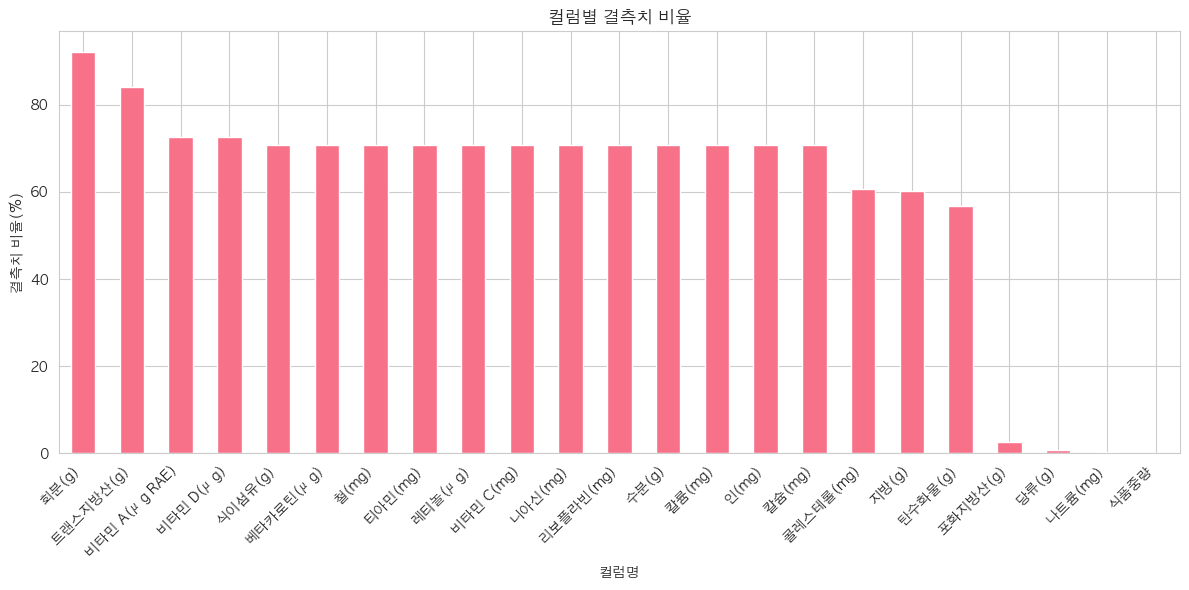

In [29]:
# 결측치 확인
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# 결측치가 있는 컬럼만 추출
missing_data = pd.DataFrame({
    '결측치 수': missing_values,
    '결측치 비율(%)': missing_percent
})
missing_data = missing_data[missing_data['결측치 수'] > 0].sort_values('결측치 수', ascending=False)

print("결측치 분석:")
display(missing_data)

# 결측치 시각화
plt.figure(figsize=(12, 6))
missing_data['결측치 비율(%)'].plot(kind='bar')
plt.title('컬럼별 결측치 비율')
plt.xlabel('컬럼명')
plt.ylabel('결측치 비율(%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. 기초 통계량 분석

수치형 변수들의 기초 통계량을 분석합니다.

영양성분 기초 통계량:


,에너지(kcal),단백질(g),지방(g),탄수화물(g),당류(g),나트륨(mg),콜레스테롤(mg),포화지방산(g),트랜스지방산(g)
count,14584.000000,14584.000000,5794.000000,6304.000000,14479.000000,14548.000000,5717.000000,14205.000000,2314.000000
mean,169.960299,6.403254,5.932014,15.921112,6.891321,265.319563,25.884158,3.159711,0.114991
std,122.701255,5.791270,6.367750,14.495292,7.638460,302.006413,49.074428,3.540870,0.244042
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,1.690000,1.130000,4.570000,1.900000,40.000000,0.010000,0.470000,0.000000
50%,145.000000,4.610000,3.355000,11.270000,4.540000,220.000000,11.080000,2.000000,0.030000
75%,263.000000,10.710000,9.377500,23.810000,9.230000,412.000000,30.090000,4.650000,0.180000
max,808.000000,59.200000,69.060000,91.000000,126.060000,7518.000000,870.150000,30.000000,4.550000


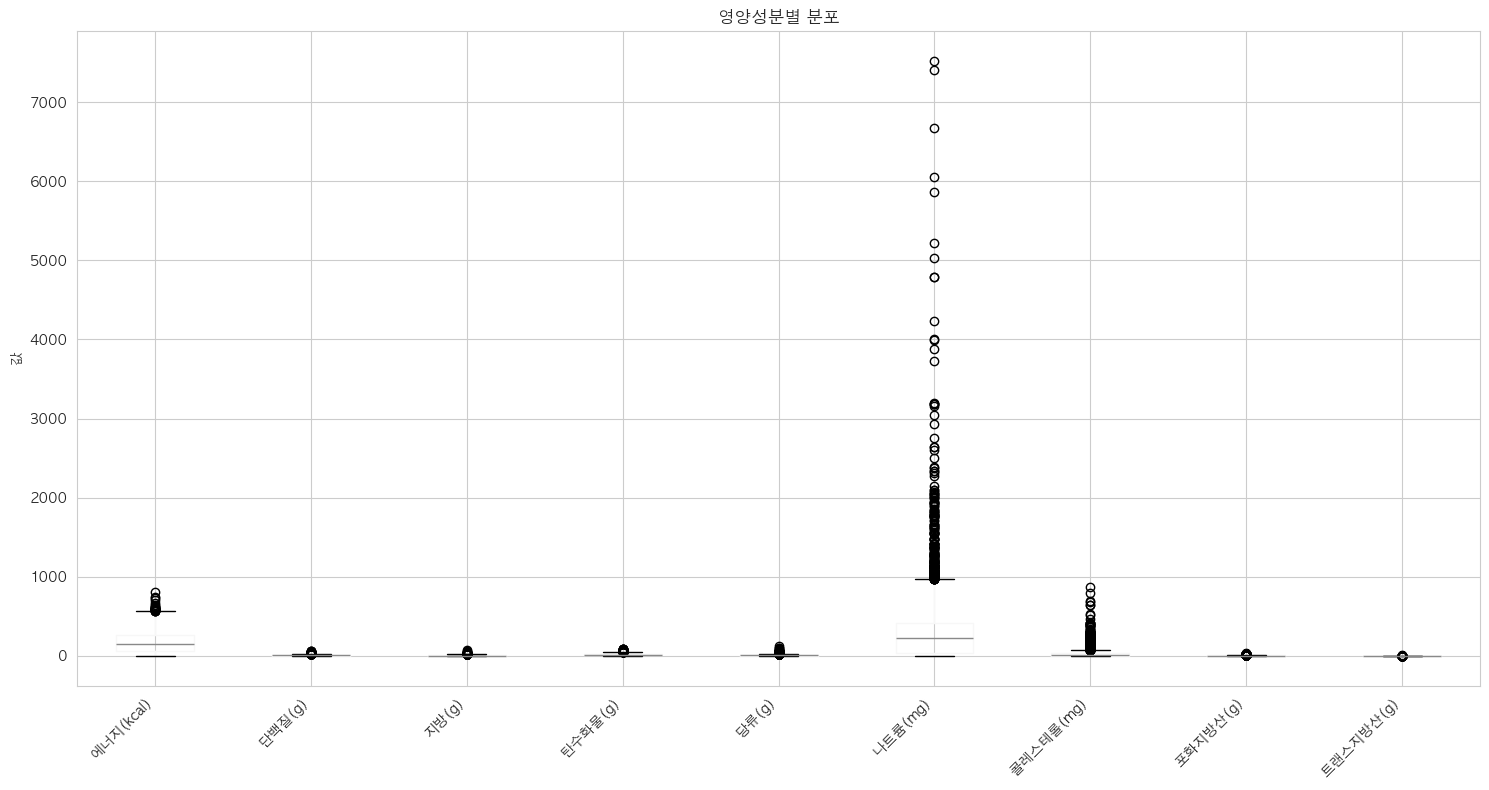

In [30]:
# 영양성분 컬럼 선택
nutrition_cols = [
    '에너지(kcal)', '단백질(g)', '지방(g)', '탄수화물(g)', '당류(g)',
    '나트륨(mg)', '콜레스테롤(mg)', '포화지방산(g)', '트랜스지방산(g)'
]

# 기초 통계량 계산
stats = df[nutrition_cols].describe()
print("영양성분 기초 통계량:")
display(stats)

# 영양성분별 박스플롯
plt.figure(figsize=(15, 8))
df[nutrition_cols].boxplot()
plt.title('영양성분별 분포')
plt.xticks(rotation=45, ha='right')
plt.ylabel('값')
plt.tight_layout()
plt.show()

## 6. 범주형 변수 분포 분석

식품 분류별 분포를 분석합니다.

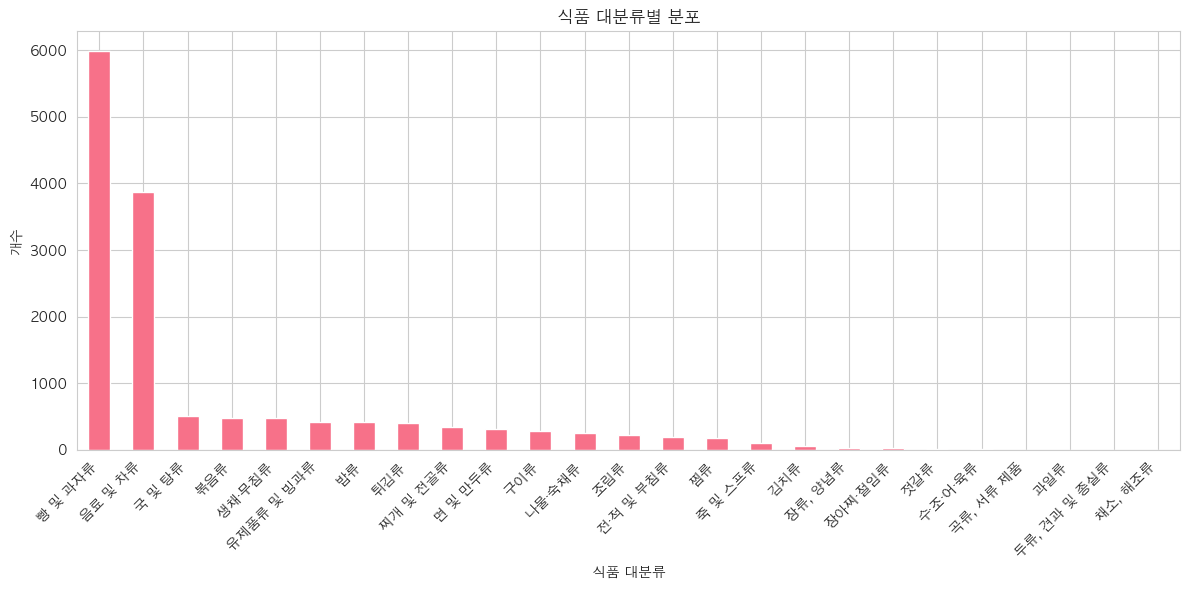

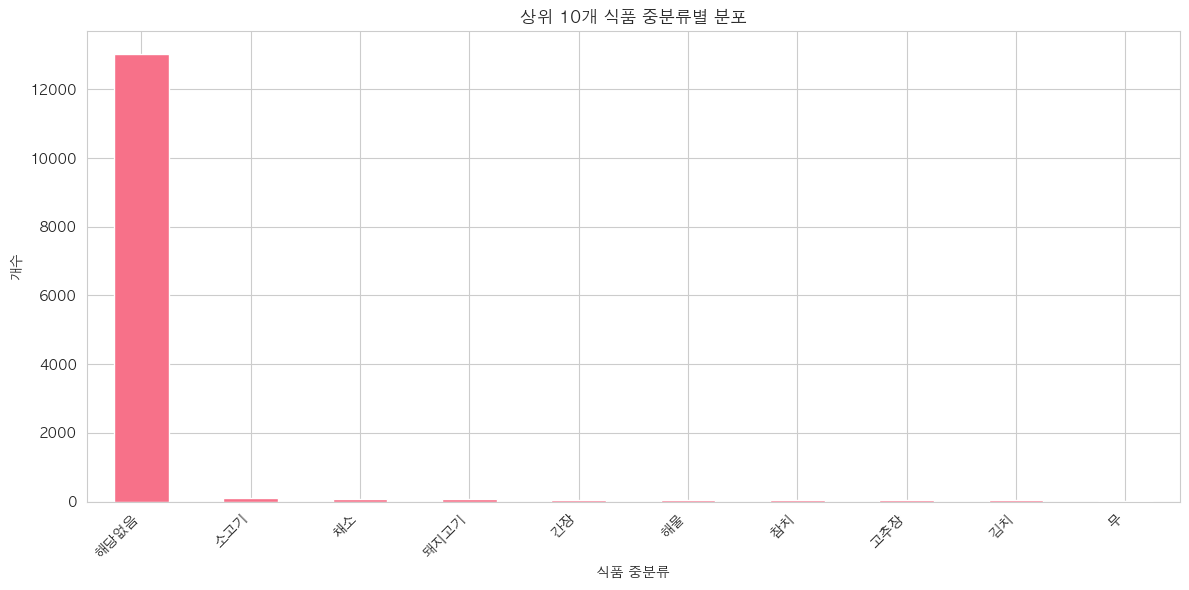

In [31]:
# 식품 대분류별 분포
plt.figure(figsize=(12, 6))
df['식품대분류명'].value_counts().plot(kind='bar')
plt.title('식품 대분류별 분포')
plt.xlabel('식품 대분류')
plt.ylabel('개수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 상위 10개 식품 중분류별 분포
plt.figure(figsize=(12, 6))
df['식품중분류명'].value_counts().head(10).plot(kind='bar')
plt.title('상위 10개 식품 중분류별 분포')
plt.xlabel('식품 중분류')
plt.ylabel('개수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. 수치형 변수 분포 분석

주요 영양성분의 분포를 분석합니다.

In [1]:
# 주요 영양성분 분포 시각화
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for idx, col in enumerate(nutrition_cols):
    # 히스토그램 그리기
    sns.histplot(data=df[col].dropna(), ax=axes[idx], kde=True)
    axes[idx].set_title(f'{col} 분포')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('빈도')
    
    # x축 레이블 회전
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 8. 영양성분 간 상관관계 분석

주요 영양성분 간의 상관관계를 분석합니다.

In [ ]:
# 상관관계 계산
correlation = df[nutrition_cols].corr()

# 히트맵 생성
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('영양성분 간 상관관계')
plt.tight_layout()
plt.show()

# 주요 상관관계 출력
print("\n주요 상관관계:")
# 상위 5개 양의 상관관계
positive_corr = correlation.unstack()
positive_corr = positive_corr[positive_corr != 1.0]  # 자기 자신과의 상관관계 제외
print("\n상위 5개 양의 상관관계:")
print(positive_corr.sort_values(ascending=False)[:5])

# 상위 5개 음의 상관관계
print("\n상위 5개 음의 상관관계:")
print(positive_corr.sort_values()[:5])